# Recall Probability by Lag

> Compute how recall varies with the spacing between repeated item presentations.

The spacing effect is a well-established memory phenomenon: repeated items benefit from wider spacing between presentations. Recall probability by lag (RPL) quantifies this by computing recall rate as a function of the number of intervening items between repeated presentations [@melton1970situation].

Lag bins are defined as: bin 0 for single-presentation items, bin $k$ for $k$ intervening items, and a final overflow bin for lags exceeding `max_lag`. A binned variant groups lags into coarser intervals (0, 1-2, 3-5, 6-8) for visualization.

This notebook is parameterized for use with [papermill](https://papermill.readthedocs.io/).

| Parameter | Description |
|-----------|-------------|
| `data_path` | Path to HDF5 dataset file |
| `figure_dir` | Directory for saving figures |
| `figure_str` | Filename for saved figure (empty string to skip saving) |
| `ylim` | Y-axis limits as tuple, or `None` for auto |
| `mixed_trial_query` | Query selecting trials with repeated items |
| `control_trial_query` | Query selecting control trials |
| `control_shuffles` | Number of control dataset shuffles |
| `mode` | `"full"` or `"binned"` |

: Notebook parameters {#tbl-parameters}

In [1]:
#| include: false
from nbdev.showdoc import show_doc

In [2]:
#| code-summary: Imports and setup
import os
import warnings

import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxcmr.analyses.rpl import (
    infer_max_lag,
    item_lag_counts,
    plot_full_rpl,
    plot_rpl,
    recall_probability_by_lag,
    run_rpl_slope_analysis,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data
from jaxcmr.repetition import make_control_dataset

warnings.filterwarnings("ignore")


def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()

In [3]:
#| code-summary: Parameters for this analysis

data_path = "data/LohnasKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
mixed_trial_query = "data['list_type'] > 3"
control_trial_query = "data['list_type'] == 1"
control_shuffles = 10
mode = "full"

In [4]:
#| code-summary: Load data and build control dataset
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)

data = load_data(data_path)
trial_mask = generate_trial_mask(data, mixed_trial_query)

control_dataset = make_control_dataset(
    data, mixed_trial_query, control_trial_query, control_shuffles
)
control_mask = generate_trial_mask(control_dataset, mixed_trial_query)

plotting_function = plot_rpl if mode == "binned" else plot_full_rpl

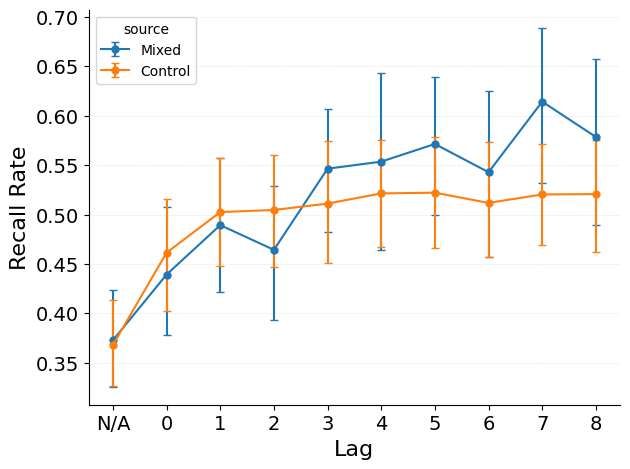

In [5]:
#| code-summary: Plot recall probability by lag
#| label: fig-rpl
#| fig-cap: "Recall probability by repetition lag for mixed and control lists."
plotting_function(
    [data, control_dataset],
    [trial_mask, control_mask],
    labels=["Mixed", "Control"],
    contrast_name="source",
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

---

## Reference

In [6]:
#| echo: false
show_doc(plot_full_rpl)

---

### plot_full_rpl

>      plot_full_rpl (datasets:Union[Sequence[jaxcmr.typing.RecallDataset],jaxcm
>                     r.typing.RecallDataset], trial_masks:Union[Sequence[jaxtyp
>                     ing.Bool[Array,'trial_count']],jaxtyping.Bool[Array,'trial
>                     _count']], color_cycle:Optional[list[str]]=None,
>                     labels:Optional[Sequence[str]]=None,
>                     contrast_name:Optional[str]=None,
>                     axis:Optional[matplotlib.axes._axes.Axes]=None,
>                     confidence_level:float=0.95)

*Plot full-resolution repetition-lag curves.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| datasets | Union |  | One or more datasets to plot. |
| trial_masks | Union |  | Boolean mask(s) selecting trials. |
| color_cycle | Optional | None | Colors for each curve. |
| labels | Optional | None | Legend labels for each curve. |
| contrast_name | Optional | None | Legend title. |
| axis | Optional | None | Existing Axes to plot on. |
| confidence_level | float | 0.95 | Confidence level for error bounds. |
| **Returns** | **Axes** |  | **Matplotlib Axes with the RPL plot.** |

In [7]:
#| echo: false
show_doc(plot_rpl)

---

### plot_rpl

>      plot_rpl (datasets:Union[Sequence[jaxcmr.typing.RecallDataset],jaxcmr.typ
>                ing.RecallDataset], trial_masks:Union[Sequence[jaxtyping.Bool[A
>                rray,'trial_count']],jaxtyping.Bool[Array,'trial_count']],
>                color_cycle:Optional[list[str]]=None,
>                labels:Optional[Sequence[str]]=None,
>                contrast_name:Optional[str]=None,
>                axis:Optional[matplotlib.axes._axes.Axes]=None,
>                confidence_level:float=0.95)

*Plot binned repetition-lag curves.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| datasets | Union |  | One or more datasets to plot. |
| trial_masks | Union |  | Boolean mask(s) selecting trials. |
| color_cycle | Optional | None | Colors for each curve. |
| labels | Optional | None | Legend labels for each curve. |
| contrast_name | Optional | None | Legend title. |
| axis | Optional | None | Existing Axes to plot on. |
| confidence_level | float | 0.95 | Confidence level for error bounds. |
| **Returns** | **Axes** |  | **Matplotlib Axes with the binned RPL plot.** |

### Computation functions

In [8]:
#| echo: false
show_doc(recall_probability_by_lag)

---

### recall_probability_by_lag

>      recall_probability_by_lag (dataset:jaxcmr.typing.RecallDataset,
>                                 max_lag:int=8)

*Recall probability by repetition lag.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| dataset | RecallDataset |  | Recall dataset with ``recalls`` and ``pres_itemnos``. |
| max_lag | int | 8 | Largest explicit lag bucket. |
| **Returns** | **Float[Array, 'lag_bins']** |  | **Recall probability per lag bin.** |

In [9]:
# Repeated item at lag 2 is recalled: probability 1.0 in that bin
recalls = jnp.array([[1, 0, 0]], dtype=jnp.int32)
presentations = jnp.array([[1, 2, 1, 3]], dtype=jnp.int32)

dataset = {
    "subject": jnp.ones((1, 1), dtype=jnp.int32),
    "listLength": jnp.full((1, 1), 4, dtype=jnp.int32),
    "pres_itemnos": presentations,
    "recalls": recalls,
}

probs = recall_probability_by_lag(dataset, max_lag=2)
# Bin 0 (single presentations): not recalled
assert float(probs[0]) == 0.0
# Bin 2 (lag=2): repeated item recalled
assert float(probs[2]) == 1.0

In [10]:
#| echo: false
show_doc(item_lag_counts)

---

### item_lag_counts

>      item_lag_counts (target_item:jaxtyping.Integer[Array,'']|int,
>                       recalls:jaxtyping.Integer[Array,'recall_events'],
>                       presentation:jaxtyping.Integer[Array,'study_events'],
>                       max_lag:int, n_bins:int)

*One-hot presented/recalled vectors for an item's lag bin.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| target_item | jaxtyping.Integer[Array, ''] \| int | Item ID to tabulate. |
| recalls | Integer[Array, 'recall_events'] | 1-indexed recalled positions; 0 for no recall. |
| presentation | Integer[Array, 'study_events'] | Item IDs at each study position. |
| max_lag | int | Largest explicit lag bucket. |
| n_bins | int | Total number of bins (``max_lag + 2``). |
| **Returns** | **tuple** | **Presented and recalled one-hot vectors.** |

### Slope tests

These functions test whether recall probability increases with spacing by fitting per-subject slopes across lag bins.

In [11]:
#| echo: false
show_doc(run_rpl_slope_analysis)

---

### run_rpl_slope_analysis

>      run_rpl_slope_analysis (dataset:jaxcmr.typing.RecallDataset,
>                              trial_mask:jaxtyping.Bool[Array,'trial_count'],
>                              comparison_dataset:jaxcmr.typing.RecallDataset, c
>                              omparison_mask:jaxtyping.Bool[Array,'trial_count'
>                              ], mode:str='full', max_lag:int|None=None)

*Slope tests for observed and comparison datasets.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| dataset | RecallDataset |  | Observed recall dataset. |
| trial_mask | Bool[Array, 'trial_count'] |  | Mask selecting observed trials. |
| comparison_dataset | RecallDataset |  | Comparison recall dataset. |
| comparison_mask | Bool[Array, 'trial_count'] |  | Mask selecting comparison trials. |
| mode | str | full | ``"full"`` or ``"binned"``. |
| max_lag | int \| None | None | Largest explicit lag bucket. |
| **Returns** | **tuple** |  | **Observed, comparison, and difference results.** |